# Real-area space-filling model

Explores `space_filling_model.real_space_filling`, which fills the convex hull of a cached OSM city graph with a Model-1 / Model-2 street network in local UTM metres while avoiding water.

Outputs are GeoDataFrames in the projected CRS (units: metres) so lengths, areas, and parameters are directly interpretable.

In [2]:
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.ops import unary_union

sys.path.insert(0, os.path.abspath('/home/lpsha/s154446/fractality/space_filling_model/'))
import real_space_filling as rsf

## 1. Load city + water

In [3]:
CITY = 'Copenhagen,_Denmark'

G = rsf.load_city_graph(CITY)
area = rsf.area_polygon_from_graph(G)
water = rsf.load_or_fetch_water(CITY, G, area)
land = rsf._land_polygon(area, water)

print(f'CRS:         {G.graph["crs"]}')
print(f'area:        {area.area/1e6:.1f} km²   (convex hull of {G.number_of_nodes()} nodes)')
print(f'water polys: {len(water)}   covering {sum(g.area for g in water.geometry)/1e6:.1f} km²')
print(f'land:        {land.area/1e6:.1f} km²')

CRS:         EPSG:32633
area:        1274.5 km²   (convex hull of 249000 nodes)
water polys: 9278   covering 135.6 km²
land:        1141.0 km²


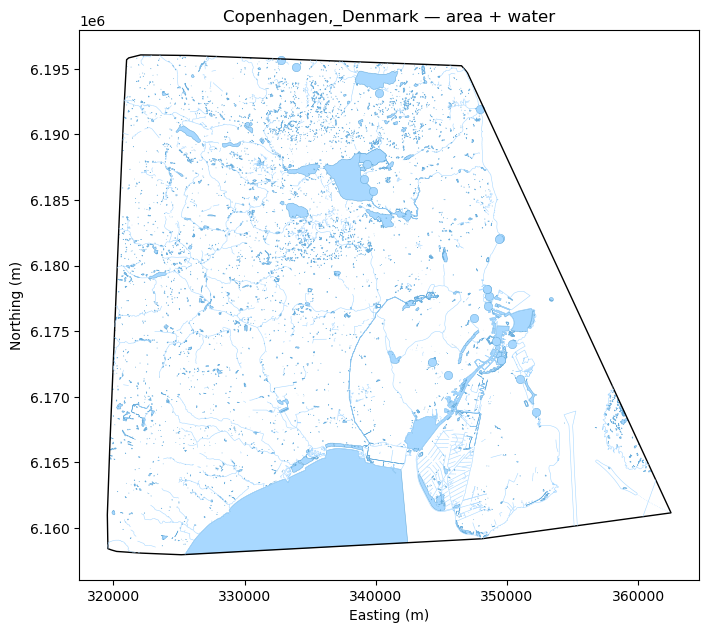

In [4]:
fig, ax = plt.subplots(figsize=(8, 8))
gpd.GeoSeries([area]).boundary.plot(ax=ax, color='black', lw=1)
if len(water):
    water.plot(ax=ax, color='#a8d8ff', edgecolor='#6aaedd', lw=0.4)
ax.set_aspect('equal'); ax.set_title(f'{CITY} — area + water')
ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
plt.show()

## 2. Run the model — 4 combinations

`init="spokes"` starts from 8 centroid→boundary spokes; `init="roads"` seeds with motorway/trunk/primary/secondary roads from the real OSM graph. `model=2` adds the area + angle bias from `space_filling.run_model`.

In [ ]:
results = {}
PARAMS = dict(min_length=400.0, max_iter=1500, seed=42, min_angle=np.pi/4)
for init in ('spokes', 'roads'):
    for model in (1, 2):
        t = time.time()
        results[(init, model)] = rsf.run_real_model(CITY, init=init, model=model, **PARAMS)
        print(f'{init:6s} model={model}: {len(results[(init,model)]["segments"]):5d} segs  ({time.time()-t:.1f}s)')

  Real model 1: converged at iter 409 with 851 segs (26 blocking, 825 streets)
spokes model=1:   825 segs  (151.1s)
  Real model 2: converged at iter 1106 with 1987 segs (26 blocking, 1961 streets)
spokes model=2:  1961 segs  (584.4s)
  Real model 1: converged at iter 125 with 17776 segs (26 blocking, 17750 streets)
roads  model=1: 17750 segs  (158.1s)


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
for ax, ((init, model), res) in zip(axes.flat, results.items()):
    gdf = rsf.to_geodataframe(res)
    gpd.GeoSeries([res['area_polygon']]).boundary.plot(ax=ax, color='black', lw=0.6)
    if len(res['water']):
        res['water'].plot(ax=ax, color='#cfe8ff', edgecolor='#6aaedd', lw=0.3)
    gdf.plot(ax=ax, color='#222', lw=0.4)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'init={init}, model={model}  —  {len(gdf)} segs, median {gdf.length.median():.0f} m')
plt.tight_layout(); plt.show()

## 3. Sanity-check: no segment crosses water

In [ ]:
for (init, model), res in results.items():
    if not len(res['water']):
        continue
    wu = unary_union(list(res['water'].geometry))
    gdf = rsf.to_geodataframe(res)
    # Length actually inside water (interior). `crosses(wu)` gives false
    # positives when wu is a GeometryCollection and a segment endpoint merely
    # touches a water boundary, so use intersection length as the real check.
    in_water = gdf.geometry.apply(lambda g: g.intersection(wu).length)
    n_cross = int((in_water > 0.1).sum())
    print(f'{init:6s} model={model}: {n_cross} of {len(gdf)} segments traverse water '
          f'(max intrusion {in_water.max():.2f} m)')

## 4. Degree and length distributions

In [ ]:
from collections import Counter
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for (init, model), res in results.items():
    gdf = rsf.to_geodataframe(res)
    label = f'{init} m{model}'
    # node degrees
    deg_counts = Counter(list(gdf['deg_start']) + list(gdf['deg_end']))
    ks = sorted(deg_counts)
    axes[0].plot(ks, [deg_counts[k] for k in ks], marker='o', label=label)
    # length distribution
    axes[1].hist(gdf.length, bins=50, histtype='step', label=label)
axes[0].set_xlabel('degree'); axes[0].set_ylabel('count'); axes[0].set_yscale('log'); axes[0].legend()
axes[1].set_xlabel('segment length (m)'); axes[1].set_ylabel('count'); axes[1].legend()
plt.tight_layout(); plt.show()

## 5. Save outputs (UTM-projected GeoPackages)

In [ ]:
# out_dir = '../data/real_space_filling'
# os.makedirs(out_dir, exist_ok=True)
# for (init, model), res in results.items():
#     gdf = rsf.to_geodataframe(res)
#     p = os.path.join(out_dir, f'{CITY}_{init}_m{model}.gpkg')
#     gdf.to_file(p, driver='GPKG')
#     print(f'wrote {p}  ({len(gdf)} segments, CRS {gdf.crs})')